# Day 6 — Recover Locked Day 5 Results

This notebook starts from the **already locked** Day 5 Random Forest (`n_estimators=500`, `class_weight=None`, no SMOTE, no threshold tuning). Model selection used KDDTrain+ validation only.

This cell **reuses kernel objects** from Day 5 if they exist. It does **not** train a new forest, change the locked model, create a new split, or use KDDTest+ for selection.

In [2]:
required_day6 = [
    "rf_final_model",
    "y_test_pred_rf",
    "rf_kddtest_metrics",
    "rf_kddtest_per_class",
    "category_order",
    "y_test",
]

print("Day 6 kernel inspection (recover Day 5 locked results; no retraining)")
print()

available = []
missing = []
for name in required_day6:
    if name in globals():
        available.append(name)
        obj = globals()[name]
        print(f"{name}: available")
        if hasattr(obj, "shape"):
            print("  shape:", obj.shape)
        elif isinstance(obj, dict):
            print("  keys:", list(obj.keys()))
        elif name == "rf_final_model":
            print("  type:", type(obj).__name__)
            print("  n_estimators:", getattr(obj, "n_estimators", None))
            print("  class_weight:", getattr(obj, "class_weight", None))
            print("  random_state:", getattr(obj, "random_state", None))
        elif name == "category_order":
            print("  value:", obj)
        print()
    else:
        missing.append(name)
        print(f"{name}: NOT available")
        print()

    print("STOPPED. Missing required variables:")
    for name in missing:
        print(f"  {name}")
    print("Run the Day 5 notebook in this kernel first. Do not retrain or reconstruct the locked model here.")
    print()
    print("Available:", ", ".join(available) if available else "(none)")
    print("KDDTest+ remains evaluation-only. No model was retrained or modified.")
else:
    print("All required Day 5 objects are available. Reusing them; nothing was retrained.")
    print("Locked model remains: Random Forest, 500 trees, class_weight=None, no SMOTE, no threshold tuning.")
    print("Available:", ", ".join(available))
    print()
    print("KDDTest+ remains evaluation-only. No model was retrained or modified.")


Day 6 kernel inspection (recover Day 5 locked results; no retraining)

rf_final_model: NOT available

STOPPED. Missing required variables:
  rf_final_model
Run the Day 5 notebook in this kernel first. Do not retrain or reconstruct the locked model here.

Available: (none)
KDDTest+ remains evaluation-only. No model was retrained or modified.
y_test_pred_rf: NOT available

STOPPED. Missing required variables:
  rf_final_model
  y_test_pred_rf
Run the Day 5 notebook in this kernel first. Do not retrain or reconstruct the locked model here.

Available: (none)
KDDTest+ remains evaluation-only. No model was retrained or modified.
rf_kddtest_metrics: NOT available

STOPPED. Missing required variables:
  rf_final_model
  y_test_pred_rf
  rf_kddtest_metrics
Run the Day 5 notebook in this kernel first. Do not retrain or reconstruct the locked model here.

Available: (none)
KDDTest+ remains evaluation-only. No model was retrained or modified.
rf_kddtest_per_class: NOT available

STOPPED. Missing 

# Day 6 — Fixed Results Table from Completed Day 5 Experiments

**Analysis only.** These tables copy already-reported Day 4 and Day 5 metrics. No model is trained, fitted, or modified. KDDTest+ is not used for selection.

In [3]:
import pandas as pd

metric_columns = [
    "Evaluation",
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "R2L Precision",
    "R2L Recall",
    "R2L F1",
    "U2R Precision",
    "U2R Recall",
    "U2R F1",
]

day6_validation_results = pd.DataFrame(
    [
        {
            "Evaluation": "Random Forest — 500 trees",
            "Accuracy": 0.998809,
            "Macro Precision": 0.974485,
            "Macro Recall": 0.931597,
            "Macro F1": 0.951031,
            "R2L Precision": 1.0000,
            "R2L Recall": 0.964824,
            "R2L F1": 0.982097,
            "U2R Precision": 0.8750,
            "U2R Recall": 0.7000,
            "U2R F1": 0.777778,
        }
    ]
)[metric_columns]

day6_kddtest_results = pd.DataFrame(
    [
        {
            "Evaluation": "Logistic Regression — no SMOTE",
            "Accuracy": 0.7610,
            "Macro Precision": 0.7746,
            "Macro Recall": 0.5637,
            "Macro F1": 0.5806,
            "R2L Precision": 0.6282,
            "R2L Recall": 0.0170,
            "R2L F1": 0.0331,
            "U2R Precision": 0.7826,
            "U2R Recall": 0.2687,
            "U2R F1": 0.4000,
        },
        {
            "Evaluation": "Logistic Regression — SMOTE",
            "Accuracy": 0.7823,
            "Macro Precision": 0.6734,
            "Macro Recall": 0.6459,
            "Macro F1": 0.5863,
            "R2L Precision": 0.8267,
            "R2L Recall": 0.1886,
            "R2L F1": 0.3071,
            "U2R Precision": 0.0688,
            "U2R Recall": 0.4776,
            "U2R F1": 0.1203,
        },
        {
            "Evaluation": "Random Forest — 500 trees",
            "Accuracy": 0.7447,
            "Macro Precision": 0.8198,
            "Macro Recall": 0.4896,
            "Macro F1": 0.5061,
            "R2L Precision": 0.9786,
            "R2L Recall": 0.0475,
            "R2L F1": 0.0906,
            "U2R Precision": 0.6667,
            "U2R Recall": 0.0597,
            "U2R F1": 0.1096,
        },
    ]
)[metric_columns]

print("Locked Random Forest — validation (Day 5, KDDTrain+ validation only)")
display(day6_validation_results)
print()
print("Completed KDDTest+ evaluations (Day 4 Logistic Regression; Day 5 locked Random Forest)")
display(day6_kddtest_results)
print()

rf_val = day6_validation_results.iloc[0]
rf_test = day6_kddtest_results.loc[
    day6_kddtest_results["Evaluation"] == "Random Forest — 500 trees"
].iloc[0]

macro_f1_drop = rf_val["Macro F1"] - rf_test["Macro F1"]
r2l_recall_drop = rf_val["R2L Recall"] - rf_test["R2L Recall"]
u2r_recall_drop = rf_val["U2R Recall"] - rf_test["U2R Recall"]

macro_f1_rel = (rf_val["Macro F1"] - rf_test["Macro F1"]) / rf_val["Macro F1"] * 100
r2l_recall_rel = (rf_val["R2L Recall"] - rf_test["R2L Recall"]) / rf_val["R2L Recall"] * 100
u2r_recall_rel = (rf_val["U2R Recall"] - rf_test["U2R Recall"]) / rf_val["U2R Recall"] * 100

print("Random Forest validation-to-KDDTest+ drops (analysis only)")
print(f"1. Macro F1 drop:           {macro_f1_drop:.4f}")
print(f"2. R2L recall drop:         {r2l_recall_drop:.4f}")
print(f"3. U2R recall drop:         {u2r_recall_drop:.4f}")
print(f"4. Macro F1 relative drop:  {macro_f1_rel:.2f}%")
print(f"5. R2L recall relative drop:{r2l_recall_rel:.2f}%")
print(f"6. U2R recall relative drop:{u2r_recall_rel:.2f}%")
print()
print("Day 5 locked model: Random Forest, 500 trees")
print("KDDTest+ was evaluation-only.")
print("No model was retrained or modified in this cell.")


Locked Random Forest — validation (Day 5, KDDTrain+ validation only)


,Evaluation,Accuracy,Macro Precision,Macro Recall,Macro F1,R2L Precision,R2L Recall,R2L F1,U2R Precision,U2R Recall,U2R F1
0,Random Forest — 500 trees,0.998809,0.974485,0.931597,0.951031,1.0,0.964824,0.982097,0.875,0.7,0.777778



Completed KDDTest+ evaluations (Day 4 Logistic Regression; Day 5 locked Random Forest)


,Evaluation,Accuracy,Macro Precision,Macro Recall,Macro F1,R2L Precision,R2L Recall,R2L F1,U2R Precision,U2R Recall,U2R F1
0,Logistic Regression — no SMOTE,0.7610,0.7746,0.5637,0.5806,0.6282,0.0170,0.0331,0.7826,0.2687,0.4000
1,Logistic Regression — SMOTE,0.7823,0.6734,0.6459,0.5863,0.8267,0.1886,0.3071,0.0688,0.4776,0.1203
2,Random Forest — 500 trees,0.7447,0.8198,0.4896,0.5061,0.9786,0.0475,0.0906,0.6667,0.0597,0.1096



Random Forest validation-to-KDDTest+ drops (analysis only)
1. Macro F1 drop:           0.4449
2. R2L recall drop:         0.9173
3. U2R recall drop:         0.6403
4. Macro F1 relative drop:  46.78%
5. R2L recall relative drop:95.08%
6. U2R recall relative drop:91.47%

Day 5 locked model: Random Forest, 500 trees
KDDTest+ was evaluation-only.
No model was retrained or modified in this cell.


# Day 6 — Class-Distribution Shift: Validation vs KDDTest+

**Data analysis only.** Compare class mix on the Day 5 KDDTrain+ **validation** split versus **KDDTest+**. No model is trained, fitted, or selected. The chart is descriptive and is **not** used for model selection.

y_validation: NOT available
y_test: NOT available

y_validation was missing. Recovered Day 5 validation labels only (test_size=0.20, stratify, random_state=42). Features were not loaded. This is the existing Day 5 split, not a new split design.
y_test was missing. Loaded KDDTest+ label column only (no features).
Label files used for missing series only. No features loaded. No model fitted.

Class distribution: KDDTrain+ validation vs KDDTest+


,Class,Validation Count,Validation %,KDDTest+ Count,KDDTest+ %,Percentage-point Difference,Relative Change %
0,Normal,13469,53.459020,9711,43.075763,-10.383257,-19.422834
1,DoS,9186,36.459615,7460,33.090845,-3.368770,-9.239731
2,Probe,2331,9.251836,2421,10.738999,1.487164,16.074254
3,R2L,199,0.789839,2885,12.797197,12.007357,1520.227981
4,U2R,10,0.039690,67,0.297197,0.257506,648.786817



1. Validation total rows: 25195
2. KDDTest+ total rows:  22544
3. Largest absolute percentage-point change: R2L
4. R2L validation:  count = 199, percentage = 0.7898%
5. R2L KDDTest+:    count = 2885, percentage = 12.7972%
6. U2R validation:  count = 10, percentage = 0.0397%
7. U2R KDDTest+:    count = 67, percentage = 0.2972%



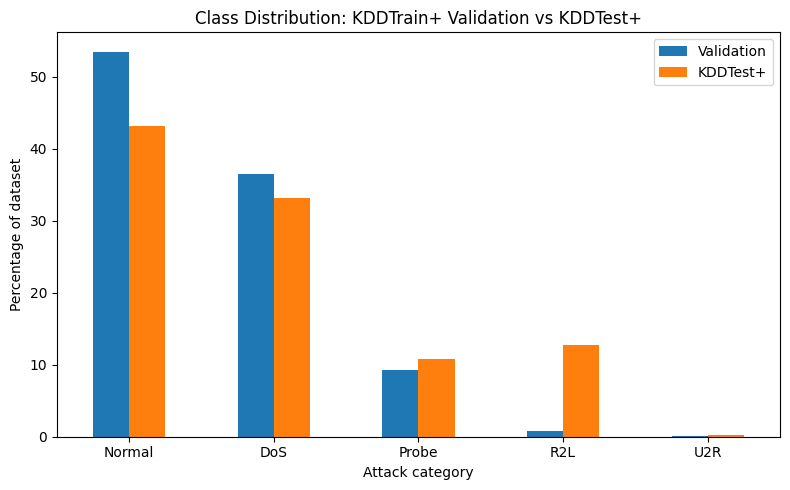


KDDTest+ remains evaluation-only.
No model was trained, modified, or selected in this analysis.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

category_order_dist = ["Normal", "DoS", "Probe", "R2L", "U2R"]

print("y_validation:", "available" if "y_validation" in globals() else "NOT available")
print("y_test:", "available" if "y_test" in globals() else "NOT available")
print()

if "y_validation" in globals() and "y_test" in globals():
    y_val_dist = y_validation
    y_test_dist = y_test
    print("Using existing y_validation and y_test from the kernel.")
else:
    if "attack_category_map" not in globals():
        attack_category_map = {
            "normal": "Normal",
            "back": "DoS",
            "land": "DoS",
            "neptune": "DoS",
            "pod": "DoS",
            "smurf": "DoS",
            "teardrop": "DoS",
            "apache2": "DoS",
            "udpstorm": "DoS",
            "processtable": "DoS",
            "mailbomb": "DoS",
            "worm": "DoS",
            "satan": "Probe",
            "ipsweep": "Probe",
            "nmap": "Probe",
            "portsweep": "Probe",
            "mscan": "Probe",
            "saint": "Probe",
            "guess_passwd": "R2L",
            "ftp_write": "R2L",
            "imap": "R2L",
            "phf": "R2L",
            "multihop": "R2L",
            "warezmaster": "R2L",
            "warezclient": "R2L",
            "spy": "R2L",
            "xlock": "R2L",
            "xsnoop": "R2L",
            "snmpguess": "R2L",
            "snmpgetattack": "R2L",
            "httptunnel": "R2L",
            "sendmail": "R2L",
            "named": "R2L",
            "buffer_overflow": "U2R",
            "loadmodule": "U2R",
            "rootkit": "U2R",
            "perl": "U2R",
            "sqlattack": "U2R",
            "xterm": "U2R",
            "ps": "U2R",
        }

    label_col = COLUMNS.index("label") if "COLUMNS" in globals() else 41

    train_labels = pd.read_csv(
        "../data/raw/KDDTrain+.txt",
        header=None,
        usecols=[label_col],
    ).iloc[:, 0]
    test_labels = pd.read_csv(
        "../data/raw/KDDTest+.txt",
        header=None,
        usecols=[label_col],
    ).iloc[:, 0]

    y_train_labels = train_labels.map(attack_category_map)
    y_test_dist = test_labels.map(attack_category_map)

    if "y_validation" in globals():
        y_val_dist = y_validation
    else:
        from sklearn.model_selection import train_test_split

        _, y_val_dist = train_test_split(
            y_train_labels,
            test_size=0.20,
            stratify=y_train_labels,
            random_state=42,
        )
        print(
            "y_validation was missing. Recovered Day 5 validation labels only "
            "(test_size=0.20, stratify, random_state=42). Features were not loaded. "
            "This is the existing Day 5 split, not a new split design."
        )

    if "y_test" not in globals():
        print("y_test was missing. Loaded KDDTest+ label column only (no features).")

    print("Label files used for missing series only. No features loaded. No model fitted.")

val_counts = y_val_dist.value_counts().reindex(category_order_dist).fillna(0).astype(int)
test_counts = y_test_dist.value_counts().reindex(category_order_dist).fillna(0).astype(int)
val_total = int(val_counts.sum())
test_total = int(test_counts.sum())
val_pct = val_counts / val_total * 100
test_pct = test_counts / test_total * 100
pp_diff = test_pct - val_pct
rel_change = (test_pct - val_pct) / val_pct * 100

day6_class_distribution = pd.DataFrame(
    {
        "Class": category_order_dist,
        "Validation Count": val_counts.values,
        "Validation %": val_pct.values,
        "KDDTest+ Count": test_counts.values,
        "KDDTest+ %": test_pct.values,
        "Percentage-point Difference": pp_diff.values,
        "Relative Change %": rel_change.values,
    }
)

print()
print("Class distribution: KDDTrain+ validation vs KDDTest+")
display(day6_class_distribution)
print()

largest_idx = day6_class_distribution["Percentage-point Difference"].abs().idxmax()
largest_class = day6_class_distribution.loc[largest_idx, "Class"]

r2l = day6_class_distribution.loc[day6_class_distribution["Class"] == "R2L"].iloc[0]
u2r = day6_class_distribution.loc[day6_class_distribution["Class"] == "U2R"].iloc[0]

print(f"1. Validation total rows: {val_total}")
print(f"2. KDDTest+ total rows:  {test_total}")
print(f"3. Largest absolute percentage-point change: {largest_class}")
print(
    f"4. R2L validation:  count = {int(r2l['Validation Count'])}, "
    f"percentage = {r2l['Validation %']:.4f}%"
)
print(
    f"5. R2L KDDTest+:    count = {int(r2l['KDDTest+ Count'])}, "
    f"percentage = {r2l['KDDTest+ %']:.4f}%"
)
print(
    f"6. U2R validation:  count = {int(u2r['Validation Count'])}, "
    f"percentage = {u2r['Validation %']:.4f}%"
)
print(
    f"7. U2R KDDTest+:    count = {int(u2r['KDDTest+ Count'])}, "
    f"percentage = {u2r['KDDTest+ %']:.4f}%"
)
print()

plot_df = day6_class_distribution.set_index("Class")[["Validation %", "KDDTest+ %"]]
ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_xlabel("Attack category")
ax.set_ylabel("Percentage of dataset")
ax.set_title("Class Distribution: KDDTrain+ Validation vs KDDTest+")
ax.legend(["Validation", "KDDTest+"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print()
print("KDDTest+ remains evaluation-only.")
print("No model was trained, modified, or selected in this analysis.")


# Day 6 — Random Forest KDDTest+ Errors by Original Attack Type

**Analysis only.** Use the locked Day 5 Random Forest predictions (`y_test_pred_rf`) to see which original KDDTest+ attack names drive low **R2L** and **U2R** recall. Do **not** retrain or change `rf_final_model`. KDDTest+ is not used for model selection.

In [5]:
import pandas as pd

print("y_test_pred_rf:", "available" if "y_test_pred_rf" in globals() else "NOT available")
print("rf_final_model:", "available" if "rf_final_model" in globals() else "NOT available")
print()

missing_attack_analysis = [
    name for name in ("y_test_pred_rf", "rf_final_model") if name not in globals()
]

if missing_attack_analysis:
    print("STOPPED. Missing variables:")
    for name in missing_attack_analysis:
        print(name)
    print("Do not retrain or reconstruct the Random Forest.")
    print("KDDTest+ was analyzed only to understand the locked model's errors.")
    print("No model selection or tuning was performed.")
    print("No model was retrained.")
else:
    if "attack_category_map" not in globals():
        attack_category_map = {
            "normal": "Normal",
            "back": "DoS",
            "land": "DoS",
            "neptune": "DoS",
            "pod": "DoS",
            "smurf": "DoS",
            "teardrop": "DoS",
            "apache2": "DoS",
            "udpstorm": "DoS",
            "processtable": "DoS",
            "mailbomb": "DoS",
            "worm": "DoS",
            "satan": "Probe",
            "ipsweep": "Probe",
            "nmap": "Probe",
            "portsweep": "Probe",
            "mscan": "Probe",
            "saint": "Probe",
            "guess_passwd": "R2L",
            "ftp_write": "R2L",
            "imap": "R2L",
            "phf": "R2L",
            "multihop": "R2L",
            "warezmaster": "R2L",
            "warezclient": "R2L",
            "spy": "R2L",
            "xlock": "R2L",
            "xsnoop": "R2L",
            "snmpguess": "R2L",
            "snmpgetattack": "R2L",
            "httptunnel": "R2L",
            "sendmail": "R2L",
            "named": "R2L",
            "buffer_overflow": "U2R",
            "loadmodule": "U2R",
            "rootkit": "U2R",
            "perl": "U2R",
            "sqlattack": "U2R",
            "xterm": "U2R",
            "ps": "U2R",
        }

    label_col = COLUMNS.index("label") if "COLUMNS" in globals() else 41
    original_attack = pd.read_csv(
        "../data/raw/KDDTest+.txt",
        header=None,
        usecols=[label_col],
    ).iloc[:, 0]
    original_attack = original_attack.reset_index(drop=True)

    pred = pd.Series(y_test_pred_rf).reset_index(drop=True)
    if len(original_attack) != len(pred):
        print("STOPPED. KDDTest+ label length does not match y_test_pred_rf.")
        print(f"  labels: {len(original_attack)}; predictions: {len(pred)}")
        print("Do not retrain or reconstruct the Random Forest.")
    else:
        day6_rf_attack_errors = pd.DataFrame(
            {
                "original_attack": original_attack,
                "actual_category": original_attack.map(attack_category_map),
                "predicted_category": pred,
            }
        )

        unmapped = day6_rf_attack_errors["actual_category"].isna().sum()
        if unmapped:
            print(f"Warning: {unmapped} rows have unmapped original attack labels.")

        dest_order = ["Normal", "DoS", "Probe", "R2L", "U2R"]

        r2l_rows = day6_rf_attack_errors.loc[
            day6_rf_attack_errors["actual_category"] == "R2L"
        ]
        r2l_groups = []
        for attack_type, grp in r2l_rows.groupby("original_attack", sort=False):
            actual_n = len(grp)
            pred_r2l_n = int((grp["predicted_category"] == "R2L").sum())
            r2l_groups.append(
                {
                    "Attack Type": attack_type,
                    "Actual Count": actual_n,
                    "Predicted R2L Count": pred_r2l_n,
                    "R2L Recall": pred_r2l_n / actual_n if actual_n else 0.0,
                }
            )
        day6_r2l_attack_type = (
            pd.DataFrame(r2l_groups).sort_values("Actual Count", ascending=False)
            .reset_index(drop=True)
        )

        print("A. R2L attack-type analysis (locked Random Forest on KDDTest+)")
        display(day6_r2l_attack_type)
        print()

        u2r_rows = day6_rf_attack_errors.loc[
            day6_rf_attack_errors["actual_category"] == "U2R"
        ]
        u2r_groups = []
        for attack_type, grp in u2r_rows.groupby("original_attack", sort=False):
            actual_n = len(grp)
            pred_u2r_n = int((grp["predicted_category"] == "U2R").sum())
            u2r_groups.append(
                {
                    "Attack Type": attack_type,
                    "Actual Count": actual_n,
                    "Predicted U2R Count": pred_u2r_n,
                    "U2R Recall": pred_u2r_n / actual_n if actual_n else 0.0,
                }
            )
        day6_u2r_attack_type = (
            pd.DataFrame(u2r_groups).sort_values("Actual Count", ascending=False)
            .reset_index(drop=True)
        )

        print("B. U2R attack-type analysis (locked Random Forest on KDDTest+)")
        display(day6_u2r_attack_type)
        print()

        r2l_dest_counts = (
            r2l_rows["predicted_category"].value_counts().reindex(dest_order).fillna(0).astype(int)
        )
        r2l_dest = pd.DataFrame(
            {
                "Predicted Category": dest_order,
                "Count": r2l_dest_counts.values,
                "Percentage": r2l_dest_counts.values / len(r2l_rows) * 100,
            }
        )
        print("C. R2L error destination (where actual R2L rows were predicted)")
        display(r2l_dest)
        print()

        u2r_dest_counts = (
            u2r_rows["predicted_category"].value_counts().reindex(dest_order).fillna(0).astype(int)
        )
        u2r_dest = pd.DataFrame(
            {
                "Predicted Category": dest_order,
                "Count": u2r_dest_counts.values,
                "Percentage": u2r_dest_counts.values / len(u2r_rows) * 100 if len(u2r_rows) else 0.0,
            }
        )
        print("D. U2R error destination (where actual U2R rows were predicted)")
        display(u2r_dest)
        print()

        print("E. Five most common R2L attack types by actual count")
        top5_r2l = day6_r2l_attack_type.head(5)
        for _, row in top5_r2l.iterrows():
            print(
                f"  {row['Attack Type']}: actual count = {int(row['Actual Count'])}, "
                f"R2L recall = {row['R2L Recall']:.4f}"
            )
        print()

        print("F. All U2R attack types present on KDDTest+")
        for _, row in day6_u2r_attack_type.iterrows():
            print(
                f"  {row['Attack Type']}: actual count = {int(row['Actual Count'])}, "
                f"U2R recall = {row['U2R Recall']:.4f}"
            )
        print()

        r2l_dom = day6_r2l_attack_type.head(3)
        r2l_poor = day6_r2l_attack_type.sort_values(
            ["R2L Recall", "Actual Count"], ascending=[True, False]
        )
        r2l_to_normal_pct = float(r2l_dest.loc[r2l_dest["Predicted Category"] == "Normal", "Percentage"].iloc[0])
        r2l_to_r2l_pct = float(r2l_dest.loc[r2l_dest["Predicted Category"] == "R2L", "Percentage"].iloc[0])
        u2r_to_normal_pct = float(u2r_dest.loc[u2r_dest["Predicted Category"] == "Normal", "Percentage"].iloc[0])
        u2r_to_u2r_pct = float(u2r_dest.loc[u2r_dest["Predicted Category"] == "U2R", "Percentage"].iloc[0])
        u2r_dom = day6_u2r_attack_type.head(3)

        print("Interpretation (factual; no new model)")
        print()
        print(
            "1. The R2L attack types that dominate KDDTest+ by actual count are: "
            + ", ".join(
                f"{r['Attack Type']} ({int(r['Actual Count'])})"
                for _, r in r2l_dom.iterrows()
            )
            + "."
        )
        print(
            "2. R2L attack types with especially poor recall include: "
            + ", ".join(
                f"{r['Attack Type']} (recall {r['R2L Recall']:.4f}, n={int(r['Actual Count'])})"
                for _, r in r2l_poor.head(5).iterrows()
            )
            + "."
        )
        print(
            "3. The U2R attack types that dominate KDDTest+ by actual count are: "
            + ", ".join(
                f"{r['Attack Type']} ({int(r['Actual Count'])})"
                for _, r in u2r_dom.iterrows()
            )
            + "."
        )
        print(
            "4. Actual R2L examples are "
            + (
                "mainly predicted as Normal "
                if r2l_to_normal_pct == r2l_dest["Percentage"].max()
                else "not exclusively predicted as Normal "
            )
            + f"({r2l_to_normal_pct:.2f}% predicted Normal; "
            f"{r2l_to_r2l_pct:.2f}% predicted R2L)."
        )
        print(
            "5. Actual U2R examples are "
            + (
                "mainly predicted as Normal "
                if u2r_to_normal_pct == u2r_dest["Percentage"].max()
                else "not exclusively predicted as Normal "
            )
            + f"({u2r_to_normal_pct:.2f}% predicted Normal; "
            f"{u2r_to_u2r_pct:.2f}% predicted U2R)."
        )
        high_volume_poor = day6_r2l_attack_type.loc[
            (day6_r2l_attack_type["Actual Count"] >= day6_r2l_attack_type["Actual Count"].median())
            & (day6_r2l_attack_type["R2L Recall"] <= day6_r2l_attack_type["R2L Recall"].median())
        ]
        print(
            "6. Aggregate R2L/U2R weakness is concentrated in particular original attack types: "
            "high-count R2L names with low recall include "
            + (
                ", ".join(high_volume_poor["Attack Type"].tolist())
                if len(high_volume_poor)
                else "(none meeting a simple high-count and low-recall split)"
            )
            + ". U2R is rare overall, so a few original names can move the class recall."
        )
        print()
        print("KDDTest+ was analyzed only to understand the locked model's errors.")
        print("No model selection or tuning was performed.")
        print("No model was retrained.")


y_test_pred_rf: NOT available
rf_final_model: NOT available

STOPPED. Missing variables:
y_test_pred_rf
rf_final_model
Do not retrain or reconstruct the Random Forest.
KDDTest+ was analyzed only to understand the locked model's errors.
No model selection or tuning was performed.
No model was retrained.


# Day 6 — Recover Day 5 Predictions from the Saved Notebook

**Recovery only.** Read `05_random_forest.ipynb` as JSON. Do **not** execute Day 5, retrain Random Forest, or reconstruct the locked model.

In [6]:
import json
from pathlib import Path

import numpy as np

day5_path = Path("../notebooks/05_random_forest.ipynb")
if not day5_path.exists():
    day5_path = Path("05_random_forest.ipynb")

with day5_path.open(encoding="utf-8") as f:
    day5_nb = json.load(f)

print("Read notebook:", day5_path.resolve())
print("Day 5 notebook was opened as JSON (not executed).")
print()

stored_marker = "Stored: y_test_pred_rf"
cells_with_marker = []
all_output_text = []

for i, cell in enumerate(day5_nb.get("cells", [])):
    source = "".join(cell.get("source", []))
    outputs = cell.get("outputs", []) or []
    output_blobs = []
    for out in outputs:
        if out.get("output_type") == "stream":
            text = out.get("text", [])
            blob = "".join(text) if isinstance(text, list) else str(text)
            output_blobs.append(blob)
        elif out.get("output_type") in ("execute_result", "display_data"):
            data = out.get("data", {})
            for key in ("text/plain", "text/html", "application/json"):
                val = data.get(key)
                if val is None:
                    continue
                blob = "".join(val) if isinstance(val, list) else str(val)
                output_blobs.append(blob)
        elif out.get("output_type") == "error":
            continue
    joined = "\n".join(output_blobs)
    all_output_text.append(joined)
    if stored_marker in joined or stored_marker in source:
        cells_with_marker.append((i, source, outputs, joined))

print(f"Cells mentioning '{stored_marker}': {len(cells_with_marker)}")


def looks_like_prediction_array(obj):
    if isinstance(obj, list) and len(obj) == 22544:
        if all(isinstance(v, str) for v in obj[:20]):
            return True
    return False


def extract_serialized_predictions(outputs):
    for out in outputs:
        if out.get("output_type") not in ("execute_result", "display_data"):
            continue
        data = out.get("data", {})
        if "application/json" in data:
            payload = data["application/json"]
            if looks_like_prediction_array(payload):
                return payload
        plain = data.get("text/plain")
        if plain is None:
            continue
        text = "".join(plain) if isinstance(plain, list) else str(plain)
        if "array([" in text and text.count("Normal") + text.count("DoS") > 1000:
            return "plain_numpy_repr"
    return None


recovered = None
recovery_note = None
for i, source, outputs, joined in cells_with_marker:
    found = extract_serialized_predictions(outputs)
    if found == "plain_numpy_repr":
        recovery_note = (
            f"Cell {i} has a NumPy text repr in output, but not a usable serialized array."
        )
    elif found is not None:
        recovered = found
        recovery_note = f"Recovered list of length {len(found)} from cell {i} output."
        break

if recovered is None:
    print("The Day 5 notebook contains the analysis output but does not contain the serialized prediction array.")
    print()
    print("Inspection of the 'Stored: y_test_pred_rf' cell:")
    if cells_with_marker:
        i, source, outputs, joined = cells_with_marker[0]
        print(f"  notebook cell index: {i}")
        print(f"  output types: {[out.get('output_type') for out in outputs]}")
        print("  The prediction vector itself was not written into notebook output.")
        print("  Only the stored-variable message and metric/report text were saved.")
    else:
        print("  Marker string was not found in notebook outputs.")
    if recovery_note:
        print(" ", recovery_note)
    print()
    print("STOPPED. y_test_pred_rf_day6 was not created.")
    print("No retraining or reconstruction was performed as a workaround.")
else:
    y_test_pred_rf_day6 = np.asarray(recovered)
    print("Recovered y_test_pred_rf_day6 from notebook output.")
    print("type:", type(y_test_pred_rf_day6))
    print("shape:", y_test_pred_rf_day6.shape)
    print("first 10 predictions:", y_test_pred_rf_day6[:10])
    print("length == 22544:", len(y_test_pred_rf_day6) == 22544)

print()
print("Serialized-object inspection (not reconstructing a model):")

metrics_object_found = False
per_class_object_found = False
per_class_table_in_output = False
metrics_numbers_in_output = False

for cell in day5_nb.get("cells", []):
    for out in cell.get("outputs", []) or []:
        data = out.get("data", {}) if out.get("output_type") in ("execute_result", "display_data") else {}
        if "application/json" in data:
            payload = data["application/json"]
            if isinstance(payload, dict) and "macro_f1" in payload and "accuracy" in payload:
                metrics_object_found = True
        plain = ""
        html = ""
        if out.get("output_type") in ("execute_result", "display_data"):
            p = data.get("text/plain")
            h = data.get("text/html")
            plain = "".join(p) if isinstance(p, list) else (p or "")
            html = "".join(h) if isinstance(h, list) else (h or "")
        if out.get("output_type") == "stream":
            t = out.get("text", [])
            plain = "".join(t) if isinstance(t, list) else str(t)
        if "precision" in plain and "R2L" in plain and "U2R" in plain:
            per_class_table_in_output = True
        if "Macro F1" in plain or "macro_f1" in plain or "Macro F1:" in plain:
            metrics_numbers_in_output = True
        if "<th>precision</th>" in html and "R2L" in html:
            per_class_table_in_output = True

print(
    "  rf_kddtest_metrics Python dict serialized in notebook output:",
    metrics_object_found,
)
print(
    "  rf_kddtest_per_class Python object serialized in notebook output:",
    per_class_object_found,
)
print(
    "  Metric numbers appear as printed/displayed analysis text:",
    metrics_numbers_in_output,
)
print(
    "  Per-class table appears as displayed DataFrame output:",
    per_class_table_in_output,
)
print("  These printed tables are not a substitute for y_test_pred_rf.")
print()
print("Day 5 notebook was read without execution.")
print("No model was retrained.")
print("No model was modified.")
print("KDDTest+ remains evaluation-only.")


Read notebook: D:\IIITB\network-traffic-anomaly-detection\notebooks\05_random_forest.ipynb
Day 5 notebook was opened as JSON (not executed).

Cells mentioning 'Stored: y_test_pred_rf': 1
The Day 5 notebook contains the analysis output but does not contain the serialized prediction array.

Inspection of the 'Stored: y_test_pred_rf' cell:
  notebook cell index: 13
  output types: ['stream', 'display_data', 'stream', 'display_data', 'stream']
  The prediction vector itself was not written into notebook output.
  Only the stored-variable message and metric/report text were saved.

STOPPED. y_test_pred_rf_day6 was not created.
No retraining or reconstruction was performed as a workaround.

Serialized-object inspection (not reconstructing a model):
  rf_kddtest_metrics Python dict serialized in notebook output: False
  rf_kddtest_per_class Python object serialized in notebook output: False
  Metric numbers appear as printed/displayed analysis text: True
  Per-class table appears as displayed

# Day 6 — Numerical Feature / Distribution Generalization

**Post-hoc analysis only** of the **locked** Day 5 Random Forest (500 trees, `class_weight=None`, no SMOTE, no threshold tuning).

Compare numerical-feature distributions on the **existing** KDDTrain+ validation split (`random_state=42`, 20% stratified) versus **KDDTest+**. No classifier is fitted. KDDTest+ is not used to change model selection. Distribution shift is **not** claimed to prove causation.

Recovered Day 5 split (test_size=0.20, stratify, random_state=42). No classifier fitted.
Numerical features: 38
X_validation shape: (25195, 41)
X_test shape: (22544, 41)

1. Numerical feature distribution shift (validation vs KDDTest+)
Standardized mean difference = (KDDTest+ mean - validation mean) / pooled std.
Pooled std = sqrt((s_val^2 + s_test^2) / 2). Undefined if pooled std is 0.


,Feature,Validation Mean,Validation Median,KDDTest+ Mean,KDDTest+ Median,Validation Std,KDDTest+ Std,Absolute Mean Difference,Standardized Mean Difference,Absolute Standardized Mean Difference
0,dst_host_serror_rate,0.284686,0.00,0.097814,0.00,0.445165,0.273139,0.186872,-0.506006,0.506006
1,dst_host_srv_serror_rate,0.278823,0.00,0.099426,0.00,0.445835,0.281866,0.179397,-0.480992,0.480992
2,serror_rate,0.284603,0.00,0.102924,0.00,0.446824,0.295367,0.181679,-0.479689,0.479689
3,srv_serror_rate,0.282756,0.00,0.103635,0.00,0.447305,0.298332,0.179121,-0.471140,0.471140
4,dst_host_rerror_rate,0.117484,0.00,0.233385,0.00,0.304165,0.387229,0.115901,0.332874,0.332874
5,rerror_rate,0.119201,0.00,0.238463,0.00,0.319676,0.416118,0.119262,0.321424,0.321424
6,srv_rerror_rate,0.120321,0.00,0.235179,0.00,0.322749,0.416215,0.114858,0.308405,0.308405
7,dst_host_srv_rerror_rate,0.119566,0.00,0.226683,0.00,0.318379,0.400875,0.107117,0.295916,0.295916
8,dst_host_srv_count,115.818893,63.00,140.750532,168.00,110.693125,111.783972,24.931640,0.224125,0.224125
9,dst_host_same_srv_rate,0.521938,0.52,0.608722,0.92,0.448499,0.435688,0.086784,0.196282,0.196282



2. Top 10 numerical features by absolute standardized mean difference


,Feature,Validation Mean,Validation Median,KDDTest+ Mean,KDDTest+ Median,Validation Std,KDDTest+ Std,Absolute Mean Difference,Standardized Mean Difference,Absolute Standardized Mean Difference
0,dst_host_serror_rate,0.284686,0.00,0.097814,0.00,0.445165,0.273139,0.186872,-0.506006,0.506006
1,dst_host_srv_serror_rate,0.278823,0.00,0.099426,0.00,0.445835,0.281866,0.179397,-0.480992,0.480992
2,serror_rate,0.284603,0.00,0.102924,0.00,0.446824,0.295367,0.181679,-0.479689,0.479689
3,srv_serror_rate,0.282756,0.00,0.103635,0.00,0.447305,0.298332,0.179121,-0.471140,0.471140
4,dst_host_rerror_rate,0.117484,0.00,0.233385,0.00,0.304165,0.387229,0.115901,0.332874,0.332874
5,rerror_rate,0.119201,0.00,0.238463,0.00,0.319676,0.416118,0.119262,0.321424,0.321424
6,srv_rerror_rate,0.120321,0.00,0.235179,0.00,0.322749,0.416215,0.114858,0.308405,0.308405
7,dst_host_srv_rerror_rate,0.119566,0.00,0.226683,0.00,0.318379,0.400875,0.107117,0.295916,0.295916
8,dst_host_srv_count,115.818893,63.00,140.750532,168.00,110.693125,111.783972,24.931640,0.224125,0.224125
9,dst_host_same_srv_rate,0.521938,0.52,0.608722,0.92,0.448499,0.435688,0.086784,0.196282,0.196282



Largest overall shifts (concise):
  dst_host_serror_rate: |SMD|=0.5060, val mean=0.2847, test mean=0.09781
  dst_host_srv_serror_rate: |SMD|=0.4810, val mean=0.2788, test mean=0.09943
  serror_rate: |SMD|=0.4797, val mean=0.2846, test mean=0.1029
  srv_serror_rate: |SMD|=0.4711, val mean=0.2828, test mean=0.1036
  dst_host_rerror_rate: |SMD|=0.3329, val mean=0.1175, test mean=0.2334

Class-conditional sample counts
  R2L: validation n=199, KDDTest+ n=2885
  U2R: validation n=10, KDDTest+ n=67

R2L — top 10 numerical features by |SMD| (validation R2L vs KDDTest+ R2L)


,Feature,Validation Mean,Validation Median,KDDTest+ Mean,KDDTest+ Median,Validation Std,KDDTest+ Std,Absolute Mean Difference,Standardized Mean Difference,Absolute Standardized Mean Difference
0,logged_in,0.904523,1.0,0.446101,0.00,0.294614,0.497173,0.458422,-1.121816,1.121816
1,dst_host_same_src_port_rate,0.563819,1.0,0.142312,0.00,0.478497,0.328611,0.421507,-1.026930,1.026930
2,dst_host_srv_count,43.587940,37.0,121.942461,98.00,38.690445,101.721599,78.354521,1.018182,1.018182
3,hot,8.763819,0.0,0.373310,0.00,12.486336,0.818252,8.390509,-0.948283,0.948283
4,dst_host_count,96.010050,11.0,187.074177,255.00,113.822651,100.403862,91.064127,0.848504,0.848504
5,dst_host_srv_diff_host_rate,0.076683,0.0,0.025775,0.00,0.104190,0.079607,0.050909,-0.549077,0.549077
6,duration,864.648241,0.0,99.221490,4.00,2787.213200,1086.445595,765.426751,-0.361854,0.361854
7,dst_host_diff_srv_rate,0.018643,0.0,0.062277,0.02,0.049835,0.163935,0.043634,0.360143,0.360143
8,num_failed_logins,0.055276,0.0,0.164298,0.00,0.229095,0.377102,0.109022,0.349426,0.349426
9,is_guest_login,0.336683,0.0,0.206932,0.00,0.473767,0.405177,0.129751,-0.294348,0.294348



U2R — top 10 numerical features by |SMD| (validation U2R vs KDDTest+ U2R)


,Feature,Validation Mean,Validation Median,KDDTest+ Mean,KDDTest+ Median,Validation Std,KDDTest+ Std,Absolute Mean Difference,Standardized Mean Difference,Absolute Standardized Mean Difference
0,dst_host_same_srv_rate,0.960,1.00,0.348209,0.22,0.126491,0.331219,0.611791,-2.440284,2.440284
1,dst_host_count,4.100,3.50,134.194030,146.00,2.923088,112.562742,130.094030,1.633922,1.633922
2,dst_host_same_src_port_rate,0.611,0.75,0.182537,0.02,0.423647,0.299547,0.428463,-1.167848,1.167848
3,same_srv_rate,0.818,1.00,1.000000,1.00,0.334624,0.000000,0.182000,0.769182,0.769182
4,logged_in,1.000,1.00,0.776119,1.00,0.000000,0.419989,0.223881,-0.753865,0.753865
5,srv_count,1.500,1.00,1.059701,1.00,0.849837,0.295450,0.440299,-0.692070,0.692070
6,num_file_creations,0.300,0.00,1.149254,0.00,0.483046,1.681033,0.849254,0.686670,0.686670
7,diff_srv_rate,0.173,0.00,0.000000,0.00,0.357959,0.000000,0.173000,-0.683484,0.683484
8,num_shells,0.000,0.00,0.328358,0.00,0.000000,0.766497,0.328358,0.605833,0.605833
9,dst_host_serror_rate,0.000,0.00,0.081791,0.00,0.000000,0.202334,0.081791,0.571678,0.571678


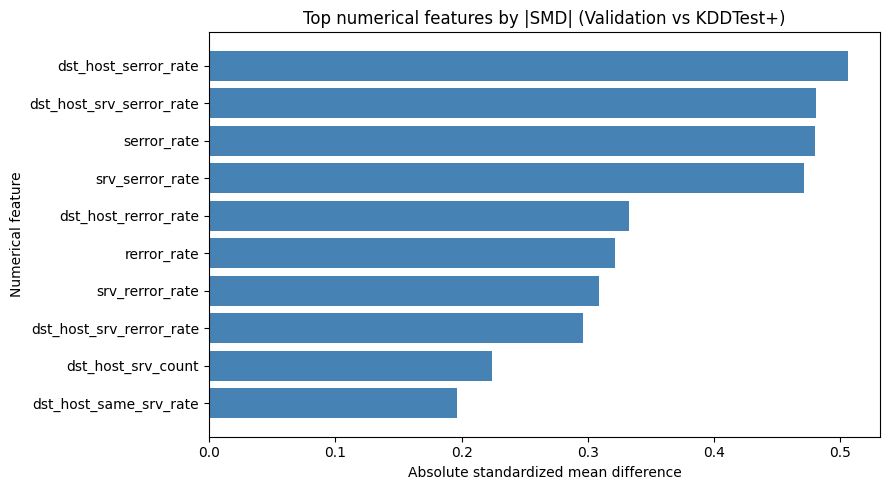

C:\Users\NITYA SHREE R\AppData\Local\Temp\ipykernel_14736\1443681120.py:274: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\NITYA SHREE R\AppData\Local\Temp\ipykernel_14736\1443681120.py:274: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


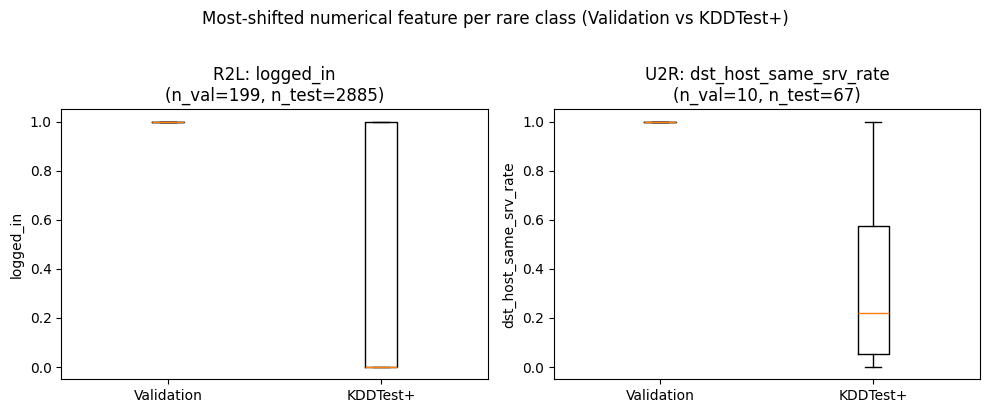


Day 6 — Distribution Shift Findings

Substantial numerical-feature distribution differences were observed (largest |SMD| = 0.5060). This is evidence of dataset/domain shift that may help explain the validation-to-test generalization gap. It does not by itself prove that these features caused the locked model's KDDTest+ errors.
Most shifted features overall (top 5 by |SMD|): dst_host_serror_rate, dst_host_srv_serror_rate, serror_rate, srv_serror_rate, dst_host_rerror_rate.
Most shifted features for R2L (top 5 by |SMD|): logged_in, dst_host_same_src_port_rate, dst_host_srv_count, hot, dst_host_count.
Most shifted features for U2R (top 5 by |SMD|): dst_host_same_srv_rate, dst_host_count, dst_host_same_src_port_rate, same_srv_rate, logged_in.
This is post-hoc analysis only. KDDTest+ was not used to select or modify a model.
The locked Random Forest was not retrained or modified.
Stored: day6_numerical_shift, day6_numerical_shift_top10, day6_r2l_numerical_shift, day6_r2l_numerical_shift_to

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

need_recover = any(
    name not in globals()
    for name in ("X_validation", "y_validation", "X_test", "y_test")
)

if need_recover:
    from sklearn.model_selection import train_test_split

    if "COLUMNS" not in globals():
        COLUMNS = [
            "duration",
            "protocol_type",
            "service",
            "flag",
            "src_bytes",
            "dst_bytes",
            "land",
            "wrong_fragment",
            "urgent",
            "hot",
            "num_failed_logins",
            "logged_in",
            "num_compromised",
            "root_shell",
            "su_attempted",
            "num_root",
            "num_file_creations",
            "num_shells",
            "num_access_files",
            "num_outbound_cmds",
            "is_host_login",
            "is_guest_login",
            "count",
            "srv_count",
            "serror_rate",
            "srv_serror_rate",
            "rerror_rate",
            "srv_rerror_rate",
            "same_srv_rate",
            "diff_srv_rate",
            "srv_diff_host_rate",
            "dst_host_count",
            "dst_host_srv_count",
            "dst_host_same_srv_rate",
            "dst_host_diff_srv_rate",
            "dst_host_same_src_port_rate",
            "dst_host_srv_diff_host_rate",
            "dst_host_serror_rate",
            "dst_host_srv_serror_rate",
            "dst_host_rerror_rate",
            "dst_host_srv_rerror_rate",
            "label",
            "difficulty",
        ]
    if "attack_category_map" not in globals():
        attack_category_map = {
            "normal": "Normal",
            "back": "DoS",
            "land": "DoS",
            "neptune": "DoS",
            "pod": "DoS",
            "smurf": "DoS",
            "teardrop": "DoS",
            "apache2": "DoS",
            "udpstorm": "DoS",
            "processtable": "DoS",
            "mailbomb": "DoS",
            "worm": "DoS",
            "satan": "Probe",
            "ipsweep": "Probe",
            "nmap": "Probe",
            "portsweep": "Probe",
            "mscan": "Probe",
            "saint": "Probe",
            "guess_passwd": "R2L",
            "ftp_write": "R2L",
            "imap": "R2L",
            "phf": "R2L",
            "multihop": "R2L",
            "warezmaster": "R2L",
            "warezclient": "R2L",
            "spy": "R2L",
            "xlock": "R2L",
            "xsnoop": "R2L",
            "snmpguess": "R2L",
            "snmpgetattack": "R2L",
            "httptunnel": "R2L",
            "sendmail": "R2L",
            "named": "R2L",
            "buffer_overflow": "U2R",
            "loadmodule": "U2R",
            "rootkit": "U2R",
            "perl": "U2R",
            "sqlattack": "U2R",
            "xterm": "U2R",
            "ps": "U2R",
        }

    feature_columns = [c for c in COLUMNS if c not in ("label", "difficulty")]
    train_df = pd.read_csv("../data/raw/KDDTrain+.txt", header=None, names=COLUMNS)
    test_df = pd.read_csv("../data/raw/KDDTest+.txt", header=None, names=COLUMNS)
    y_train_all = train_df["label"].map(attack_category_map)
    X_train_all = train_df[feature_columns]
    X_test = test_df[feature_columns]
    y_test = test_df["label"].map(attack_category_map)
    _, X_validation, _, y_validation = train_test_split(
        X_train_all,
        y_train_all,
        test_size=0.20,
        stratify=y_train_all,
        random_state=42,
    )
    print("Recovered Day 5 split (test_size=0.20, stratify, random_state=42). No classifier fitted.")
else:
    print("Using existing X_validation, y_validation, X_test, y_test.")

categorical_features = ["protocol_type", "service", "flag"]
if "numerical_features" in globals():
    day6_numerical_features = list(numerical_features)
else:
    day6_numerical_features = [
        c for c in X_validation.columns if c not in categorical_features
    ]

print("Numerical features:", len(day6_numerical_features))
print("X_validation shape:", X_validation.shape)
print("X_test shape:", X_test.shape)
print()


def standardized_mean_difference(a, b):
    a = pd.to_numeric(a, errors="coerce").dropna()
    b = pd.to_numeric(b, errors="coerce").dropna()
    mean_a, mean_b = a.mean(), b.mean()
    std_a, std_b = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt((std_a ** 2 + std_b ** 2) / 2.0)
    if not np.isfinite(pooled) or pooled == 0:
        return np.nan
    return (mean_b - mean_a) / pooled


def feature_shift_table(X_val, X_te, feature_names):
    rows = []
    for feat in feature_names:
        v = pd.to_numeric(X_val[feat], errors="coerce")
        t = pd.to_numeric(X_te[feat], errors="coerce")
        val_mean, test_mean = v.mean(), t.mean()
        smd = standardized_mean_difference(v, t)
        rows.append(
            {
                "Feature": feat,
                "Validation Mean": val_mean,
                "Validation Median": v.median(),
                "KDDTest+ Mean": test_mean,
                "KDDTest+ Median": t.median(),
                "Validation Std": v.std(ddof=1),
                "KDDTest+ Std": t.std(ddof=1),
                "Absolute Mean Difference": abs(test_mean - val_mean),
                "Standardized Mean Difference": smd,
                "Absolute Standardized Mean Difference": abs(smd) if pd.notna(smd) else np.nan,
            }
        )
    return pd.DataFrame(rows)


day6_numerical_shift = feature_shift_table(
    X_validation, X_test, day6_numerical_features
).sort_values("Absolute Standardized Mean Difference", ascending=False, na_position="last")
day6_numerical_shift = day6_numerical_shift.reset_index(drop=True)

print("1. Numerical feature distribution shift (validation vs KDDTest+)")
print("Standardized mean difference = (KDDTest+ mean - validation mean) / pooled std.")
print("Pooled std = sqrt((s_val^2 + s_test^2) / 2). Undefined if pooled std is 0.")
display(day6_numerical_shift)

day6_numerical_shift_top10 = day6_numerical_shift.head(10).copy()
print()
print("2. Top 10 numerical features by absolute standardized mean difference")
display(day6_numerical_shift_top10)

print()
print("Largest overall shifts (concise):")
for _, r in day6_numerical_shift_top10.head(5).iterrows():
    print(
        f"  {r['Feature']}: |SMD|={r['Absolute Standardized Mean Difference']:.4f}, "
        f"val mean={r['Validation Mean']:.4g}, test mean={r['KDDTest+ Mean']:.4g}"
    )


def class_conditional_shift(label):
    val_mask = y_validation == label
    test_mask = y_test == label
    n_val, n_test = int(val_mask.sum()), int(test_mask.sum())
    if n_val == 0 or n_test == 0:
        return None, n_val, n_test
    table = feature_shift_table(
        X_validation.loc[val_mask],
        X_test.loc[test_mask],
        day6_numerical_features,
    ).sort_values("Absolute Standardized Mean Difference", ascending=False, na_position="last")
    return table.reset_index(drop=True), n_val, n_test


day6_r2l_numerical_shift, day6_r2l_n_validation, day6_r2l_n_kddtest = class_conditional_shift("R2L")
day6_u2r_numerical_shift, day6_u2r_n_validation, day6_u2r_n_kddtest = class_conditional_shift("U2R")

print()
print("Class-conditional sample counts")
print(f"  R2L: validation n={day6_r2l_n_validation}, KDDTest+ n={day6_r2l_n_kddtest}")
print(f"  U2R: validation n={day6_u2r_n_validation}, KDDTest+ n={day6_u2r_n_kddtest}")

if day6_r2l_numerical_shift is None:
    print("R2L is not present in both datasets; R2L feature-shift table skipped.")
    day6_r2l_numerical_shift_top10 = None
else:
    day6_r2l_numerical_shift_top10 = day6_r2l_numerical_shift.head(10).copy()
    print()
    print("R2L — top 10 numerical features by |SMD| (validation R2L vs KDDTest+ R2L)")
    display(day6_r2l_numerical_shift_top10)

if day6_u2r_numerical_shift is None:
    print("U2R is not present in both datasets; U2R feature-shift table skipped.")
    day6_u2r_numerical_shift_top10 = None
else:
    day6_u2r_numerical_shift_top10 = day6_u2r_numerical_shift.head(10).copy()
    print()
    print("U2R — top 10 numerical features by |SMD| (validation U2R vs KDDTest+ U2R)")
    display(day6_u2r_numerical_shift_top10)

# Plot 1: overall top 10 |SMD|
fig1, ax1 = plt.subplots(figsize=(9, 5))
plot1 = day6_numerical_shift_top10.iloc[::-1]
ax1.barh(plot1["Feature"], plot1["Absolute Standardized Mean Difference"], color="steelblue")
ax1.set_xlabel("Absolute standardized mean difference")
ax1.set_ylabel("Numerical feature")
ax1.set_title("Top numerical features by |SMD| (Validation vs KDDTest+)")
plt.tight_layout()
plt.show()

# Plot 2: most-shifted R2L and U2R features — validation vs KDDTest+
fig2, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, title, table, n_val, n_te, y_val, y_te in (
    (
        axes[0],
        "R2L",
        day6_r2l_numerical_shift_top10,
        day6_r2l_n_validation,
        day6_r2l_n_kddtest,
        "R2L",
        "R2L",
    ),
    (
        axes[1],
        "U2R",
        day6_u2r_numerical_shift_top10,
        day6_u2r_n_validation,
        day6_u2r_n_kddtest,
        "U2R",
        "U2R",
    ),
):
    if table is None or len(table) == 0:
        ax.set_title(f"{title}: comparison not available")
        continue
    feat = table.iloc[0]["Feature"]
    val_vals = pd.to_numeric(
        X_validation.loc[y_validation == y_val, feat], errors="coerce"
    ).dropna()
    te_vals = pd.to_numeric(X_test.loc[y_test == y_te, feat], errors="coerce").dropna()
    ax.boxplot(
        [val_vals, te_vals],
        labels=["Validation", "KDDTest+"],
        showfliers=False,
    )
    ax.set_title(f"{title}: {feat}\n(n_val={n_val}, n_test={n_te})")
    ax.set_ylabel(feat)
plt.suptitle("Most-shifted numerical feature per rare class (Validation vs KDDTest+)", y=1.02)
plt.tight_layout()
plt.show()

top_overall = ", ".join(day6_numerical_shift_top10["Feature"].head(5).tolist())
top_r2l = (
    ", ".join(day6_r2l_numerical_shift_top10["Feature"].head(5).tolist())
    if day6_r2l_numerical_shift_top10 is not None
    else "not available"
)
top_u2r = (
    ", ".join(day6_u2r_numerical_shift_top10["Feature"].head(5).tolist())
    if day6_u2r_numerical_shift_top10 is not None
    else "not available"
)
max_smd = day6_numerical_shift["Absolute Standardized Mean Difference"].max(skipna=True)

print()
print("Day 6 — Distribution Shift Findings")
print()
print(
    "Substantial numerical-feature distribution differences were "
    + (
        "observed "
        if pd.notna(max_smd) and max_smd >= 0.2
        else "limited "
    )
    + f"(largest |SMD| = {max_smd:.4f}). "
    "This is evidence of dataset/domain shift that may help explain the "
    "validation-to-test generalization gap. It does not by itself prove that "
    "these features caused the locked model's KDDTest+ errors."
)
print(f"Most shifted features overall (top 5 by |SMD|): {top_overall}.")
print(f"Most shifted features for R2L (top 5 by |SMD|): {top_r2l}.")
print(f"Most shifted features for U2R (top 5 by |SMD|): {top_u2r}.")
print("This is post-hoc analysis only. KDDTest+ was not used to select or modify a model.")
print("The locked Random Forest was not retrained or modified.")
print("Stored: day6_numerical_shift, day6_numerical_shift_top10, "
      "day6_r2l_numerical_shift, day6_r2l_numerical_shift_top10, "
      "day6_u2r_numerical_shift, day6_u2r_numerical_shift_top10.")


# Day 6 — KDDTest+ Error Analysis of the Locked Random Forest

**Post-hoc analysis only.** Explain the already-observed KDDTest+ errors of the **locked** Day 5 Random Forest (500 trees). Use stored/reported results only. Do **not** retrain, reconstruct predictions, or use KDDTest+ for model selection.

In [8]:
import numpy as np
import pandas as pd

classes = ["Normal", "DoS", "Probe", "R2L", "U2R"]

# Already-reported locked RF 500-tree validation per-class (Day 5 tree comparison / lock)
reported_val = {
    "R2L": {"precision": 1.0000, "recall": 0.964824, "f1": 0.982097},
    "U2R": {"precision": 0.8750, "recall": 0.7000, "f1": 0.777778},
}
# Already-reported KDDTest+ per-class table from Day 5 evaluation output
reported_test = {
    "Normal": {"precision": 0.642372, "recall": 0.973844, "f1": 0.774117},
    "DoS": {"precision": 0.961345, "recall": 0.770107, "f1": 0.855165},
    "Probe": {"precision": 0.850000, "recall": 0.596861, "f1": 0.701286},
    "R2L": {"precision": 0.978571, "recall": 0.047487, "f1": 0.090579},
    "U2R": {"precision": 0.666667, "recall": 0.059701, "f1": 0.109589},
}
# Already-displayed Day 5 KDDTest+ confusion matrix (rows=actual, columns=predicted)
reported_cm = pd.DataFrame(
    [
        [9457, 67, 186, 0, 1],
        [1649, 5745, 66, 0, 0],
        [812, 164, 1445, 0, 0],
        [2744, 0, 3, 137, 1],
        [60, 0, 0, 3, 4],
    ],
    index=["Actual " + c for c in classes],
    columns=["Predicted " + c for c in classes],
)

print("1. Validation vs KDDTest+ per-class comparison (locked Random Forest, 500 trees)")
print()

val_pc = None
if "rf_tree_count_comparison" in globals():
    match = rf_tree_count_comparison.loc[rf_tree_count_comparison["n_estimators"] == 500]
    if len(match) == 1:
        val_pc = "rf_tree_count_comparison (n_estimators=500)"
if val_pc is None and "day6_validation_results" in globals():
    val_pc = "day6_validation_results"

test_pc_source = None
if "rf_kddtest_per_class" in globals():
    test_pc = rf_kddtest_per_class
    test_pc_source = "rf_kddtest_per_class"
else:
    test_pc = pd.DataFrame(reported_test).T
    test_pc_source = "Day 5 reported KDDTest+ per-class table (not recomputed)"

missing_val_classes = [c for c in classes if c not in reported_val]
print(
    "Validation per-class P/R/F1 for Normal, DoS, and Probe were not stored "
    "for the locked 500-tree model (only macros plus R2L/U2R were reported). "
    "Those validation cells are left missing rather than reconstructed from predictions."
)
print(f"KDDTest+ per-class source: {test_pc_source}")
print(f"Validation R2L/U2R source: {val_pc or 'Day 5 reported 500-tree validation metrics'}")
print()

rows = []
for c in classes:
    if c in reported_val:
        vp, vr, vf = reported_val[c]["precision"], reported_val[c]["recall"], reported_val[c]["f1"]
        if val_pc == "day6_validation_results" and c in ("R2L", "U2R"):
            vr = float(day6_validation_results.iloc[0][f"{c} Recall"])
            vp = float(day6_validation_results.iloc[0][f"{c} Precision"])
            vf = float(day6_validation_results.iloc[0][f"{c} F1"])
        if val_pc == "rf_tree_count_comparison (n_estimators=500)":
            row500 = rf_tree_count_comparison.loc[
                rf_tree_count_comparison["n_estimators"] == 500
            ].iloc[0]
            vp = float(row500[f"{c} Precision"])
            vr = float(row500[f"{c} Recall"])
            vf = float(row500[f"{c} F1"])
    else:
        vp = vr = vf = np.nan
    tp = float(test_pc.loc[c, "precision"])
    tr = float(test_pc.loc[c, "recall"])
    tf = float(test_pc.loc[c, "f1"])
    f1_abs = tf - vf if pd.notna(vf) else np.nan
    f1_rel = (tf - vf) / vf * 100 if pd.notna(vf) and vf != 0 else np.nan
    rows.append(
        {
            "Class": c,
            "Validation Precision": vp,
            "Validation Recall": vr,
            "Validation F1": vf,
            "KDDTest+ Precision": tp,
            "KDDTest+ Recall": tr,
            "KDDTest+ F1": tf,
            "F1 Absolute Change": f1_abs,
            "F1 Relative Change (%)": f1_rel,
        }
    )

day6_error_per_class_comparison = pd.DataFrame(rows)
display(day6_error_per_class_comparison)

print()
print("2. KDDTest+ confusion matrix (existing Day 5 result; not recomputed from predictions)")
if "rf_test_cm_df" in globals():
    day6_kddtest_confusion = rf_test_cm_df.copy()
    print("Source: rf_test_cm_df")
elif "rf_test_cm" in globals():
    day6_kddtest_confusion = pd.DataFrame(
        rf_test_cm,
        index=["Actual " + c for c in classes],
        columns=["Predicted " + c for c in classes],
    )
    print("Source: rf_test_cm")
else:
    day6_kddtest_confusion = reported_cm.copy()
    print("Source: Day 5 displayed KDDTest+ confusion matrix (serialized notebook output).")
    print("y_test_pred_rf was not reconstructed.")
display(day6_kddtest_confusion)

cm = day6_kddtest_confusion
error_pairs = []
for actual in classes:
    for pred in classes:
        if actual == pred:
            continue
        n = int(cm.loc["Actual " + actual, "Predicted " + pred])
        error_pairs.append((actual, pred, n))
error_pairs = sorted(error_pairs, key=lambda x: x[2], reverse=True)

print()
print("Largest actual→predicted error directions (off-diagonal counts):")
for actual, pred, n in error_pairs[:8]:
    print(f"  {actual} → {pred}: {n}")

print()
print("Requested Normal-confusion directions:")
for actual in ("R2L", "U2R", "DoS", "Probe"):
    n = int(cm.loc["Actual " + actual, "Predicted Normal"])
    support = int(cm.loc["Actual " + actual].sum())
    pct = n / support * 100 if support else np.nan
    print(f"  {actual} → Normal: {n}  ({pct:.2f}% of actual {actual})")

print()
print("3. R2L analysis (locked Random Forest; previously reported numbers)")
print("  validation R2L support = 199")
print("  KDDTest+ R2L support = 2885")
print("  validation R2L recall = 0.964824")
print("  KDDTest+ R2L recall = 0.047487")
print("  validation R2L F1 = 0.982097")
print("  KDDTest+ R2L F1 = 0.090579")
print("  KDDTest+ R2L false negatives = 2748")
print("  KDDTest+ R2L false positives = 3")
print()
print(
    "The locked model has high R2L precision but extremely poor R2L recall on KDDTest+. "
    "It is conservative about predicting R2L (only 3 false positives) and misses most "
    "actual R2L attacks (2748 false negatives; 2744 of 2885 actual R2L rows go to Normal)."
)

print()
print("4. U2R analysis (locked Random Forest; previously reported numbers)")
print("  validation U2R support = 10")
print("  KDDTest+ U2R support = 67")
print("  validation U2R recall = 0.7000")
print("  KDDTest+ U2R recall = 0.059701")
print("  validation U2R F1 = 0.777778")
print("  KDDTest+ U2R F1 = 0.109589")
print("  KDDTest+ U2R false negatives = 63")
print()
print(
    "The validation U2R estimate is based on only 10 examples, so its apparent "
    "validation recall/F1 is highly uncertain and is not representative of the "
    "larger and different KDDTest+ U2R distribution (67 examples). On KDDTest+, "
    "60 of 67 actual U2R rows are predicted as Normal."
)

print()
print("5. Connection to already-computed distribution shift")
print()

if "day6_class_distribution" in globals():
    dist = day6_class_distribution.set_index("Class")
    r2l_val_pct = float(dist.loc["R2L", "Validation %"])
    r2l_te_pct = float(dist.loc["R2L", "KDDTest+ %"])
    u2r_val_pct = float(dist.loc["U2R", "Validation %"])
    u2r_te_pct = float(dist.loc["U2R", "KDDTest+ %"])
    print("Source: day6_class_distribution")
else:
    r2l_val_pct, r2l_te_pct = 0.7898, 12.7972
    u2r_val_pct, u2r_te_pct = 0.0397, 0.2972
    print("STOPPED subsection detail: day6_class_distribution is not in this kernel.")
    print("Using the already-reported prevalence figures from the Day 6 distribution section.")

print(
    f"  R2L prevalence: validation {r2l_val_pct:.4f}% → KDDTest+ {r2l_te_pct:.4f}%"
)
print(
    f"  U2R prevalence: validation {u2r_val_pct:.4f}% → KDDTest+ {u2r_te_pct:.4f}%"
)

if "day6_numerical_shift" in globals():
    overall_max = float(
        day6_numerical_shift["Absolute Standardized Mean Difference"].max(skipna=True)
    )
    overall_top = day6_numerical_shift.dropna(
        subset=["Absolute Standardized Mean Difference"]
    ).head(3)
    print(f"  Overall largest |SMD| = {overall_max:.4f}")
    print("  Top overall shifted features:", ", ".join(overall_top["Feature"].tolist()))
else:
    overall_max = 0.5060
    print("STOPPED subsection detail: day6_numerical_shift is not in this kernel.")
    print(f"  Using already-reported overall largest |SMD| = {overall_max:.4f}")

if "day6_r2l_numerical_shift" in globals() and day6_r2l_numerical_shift is not None:
    n_gt1 = int(
        (day6_r2l_numerical_shift["Absolute Standardized Mean Difference"] > 1).sum()
    )
    r2l_top = day6_r2l_numerical_shift.head(3)
    print(
        f"  R2L conditional |SMD| > 1 for {n_gt1} numerical features; "
        "top features: " + ", ".join(r2l_top["Feature"].tolist())
    )
else:
    print("STOPPED subsection detail: day6_r2l_numerical_shift is not in this kernel.")
    print("  Already reported: R2L has very large conditional shifts, including |SMD| > 1 for several features.")

if "day6_u2r_numerical_shift" in globals() and day6_u2r_numerical_shift is not None:
    u2r_top1 = day6_u2r_numerical_shift.iloc[0]
    print(
        f"  U2R largest conditional |SMD| = {u2r_top1['Absolute Standardized Mean Difference']:.4f} "
        f"for {u2r_top1['Feature']}"
    )
else:
    print("STOPPED subsection detail: day6_u2r_numerical_shift is not in this kernel.")
    print("  Already reported: U2R |SMD| = 2.4403 for dst_host_same_srv_rate.")

print()
print(
    "These class-mix and numerical-distribution differences are consistent with "
    "dataset/domain shift. They may help explain why validation R2L/U2R scores "
    "did not carry over to KDDTest+. They provide evidence of a shifted operating "
    "distribution and plausibly contribute to the generalization gap. They do not "
    "prove that any specific feature caused the locked model's errors."
)

print()
print("Day 6 — Error Analysis Conclusion")
print()
print(
    "The locked Random Forest generalized poorly from KDDTrain+ validation to KDDTest+. "
    "The largest weakness is rare-attack detection, particularly R2L and U2R recall. "
    "KDDTest+ has a substantially different attack-class composition (R2L rises from "
    f"{r2l_val_pct:.4f}% to {r2l_te_pct:.4f}%; U2R from {u2r_val_pct:.4f}% to {u2r_te_pct:.4f}%). "
    "Numerical feature distributions also shift substantially "
    f"(overall largest |SMD| = {overall_max:.4f}). "
    "R2L and U2R conditional distributions show especially large shifts. "
    "These observations provide evidence consistent with dataset/domain shift. "
    "They do not prove causal feature-level explanations. "
    "KDDTest+ remains evaluation/diagnostic only. "
    "The locked Random Forest was not retrained, modified, tuned, or replaced."
)
print()
print("Day 6 error analysis completed. No model retraining, tuning, replacement, or KDDTest+-based model selection was performed.")


1. Validation vs KDDTest+ per-class comparison (locked Random Forest, 500 trees)

Validation per-class P/R/F1 for Normal, DoS, and Probe were not stored for the locked 500-tree model (only macros plus R2L/U2R were reported). Those validation cells are left missing rather than reconstructed from predictions.
KDDTest+ per-class source: Day 5 reported KDDTest+ per-class table (not recomputed)
Validation R2L/U2R source: day6_validation_results



,Class,Validation Precision,Validation Recall,Validation F1,KDDTest+ Precision,KDDTest+ Recall,KDDTest+ F1,F1 Absolute Change,F1 Relative Change (%)
0,Normal,NaN,NaN,NaN,0.642372,0.973844,0.774117,NaN,NaN
1,DoS,NaN,NaN,NaN,0.961345,0.770107,0.855165,NaN,NaN
2,Probe,NaN,NaN,NaN,0.850000,0.596861,0.701286,NaN,NaN
3,R2L,1.000,0.964824,0.982097,0.978571,0.047487,0.090579,-0.891518,-90.77698
4,U2R,0.875,0.700000,0.777778,0.666667,0.059701,0.109589,-0.668189,-85.90999



2. KDDTest+ confusion matrix (existing Day 5 result; not recomputed from predictions)
Source: Day 5 displayed KDDTest+ confusion matrix (serialized notebook output).
y_test_pred_rf was not reconstructed.


,Predicted Normal,Predicted DoS,Predicted Probe,Predicted R2L,Predicted U2R
Actual Normal,9457,67,186,0,1
Actual DoS,1649,5745,66,0,0
Actual Probe,812,164,1445,0,0
Actual R2L,2744,0,3,137,1
Actual U2R,60,0,0,3,4



Largest actual→predicted error directions (off-diagonal counts):
  R2L → Normal: 2744
  DoS → Normal: 1649
  Probe → Normal: 812
  Normal → Probe: 186
  Probe → DoS: 164
  Normal → DoS: 67
  DoS → Probe: 66
  U2R → Normal: 60

Requested Normal-confusion directions:
  R2L → Normal: 2744  (95.11% of actual R2L)
  U2R → Normal: 60  (89.55% of actual U2R)
  DoS → Normal: 1649  (22.10% of actual DoS)
  Probe → Normal: 812  (33.54% of actual Probe)

3. R2L analysis (locked Random Forest; previously reported numbers)
  validation R2L support = 199
  KDDTest+ R2L support = 2885
  validation R2L recall = 0.964824
  KDDTest+ R2L recall = 0.047487
  validation R2L F1 = 0.982097
  KDDTest+ R2L F1 = 0.090579
  KDDTest+ R2L false negatives = 2748
  KDDTest+ R2L false positives = 3

The locked model has high R2L precision but extremely poor R2L recall on KDDTest+. It is conservative about predicting R2L (only 3 false positives) and misses most actual R2L attacks (2748 false negatives; 2744 of 2885 a

# Day 6 — Final Findings and Takeaways

Reporting/synthesis only. No new experiments. The Day 5 locked model is unchanged.

## 1. Locked model

- Random Forest
- 500 trees
- `class_weight=None`
- no SMOTE
- no threshold tuning
- selected using **KDDTrain+ validation only**

## 2. Validation performance

- Accuracy = 0.998809
- Macro Precision = 0.974485
- Macro Recall = 0.931597
- Macro F1 = 0.951031
- R2L F1 = 0.982097
- U2R F1 = 0.777778

## 3. KDDTest+ performance

- Accuracy = 0.7447
- Macro Precision = 0.8198
- Macro Recall = 0.4896
- Macro F1 = 0.5061
- R2L F1 = 0.0906
- U2R F1 = 0.1096

## 4. Generalization gap

- Macro F1 drop = 0.4449
- relative Macro F1 drop = 46.78%
- R2L recall drop = 0.9173
- U2R recall drop = 0.6403

## 5. Dominant KDDTest+ errors

- R2L → Normal = 2744
- U2R → Normal = 60
- DoS → Normal = 1649
- Probe → Normal = 812

## 6. Distribution shift

- R2L prevalence: 0.7898% validation → 12.7972% KDDTest+
- U2R prevalence: 0.0397% validation → 0.2972% KDDTest+
- largest overall numerical |SMD| = 0.5060
- R2L and U2R conditional feature distributions show substantially larger shifts

## 7. Interpretation

The locked Random Forest looked nearly perfect on the KDDTrain+ validation split, then lost a large share of Macro F1 on KDDTest+, especially R2L and U2R recall. Most missed R2L and U2R rows were labeled Normal. KDDTest+ also has a very different class mix and shifted numerical features, including larger R2L/U2R-conditional shifts. That pattern is **consistent with dataset/domain shift** and **helps explain** why validation scores did not transfer. This analysis does **not** establish that any individual feature caused the errors.

## 8. Experimental integrity

KDDTest+ was **evaluation/diagnostic only**. It was **not** used for model selection. The locked Random Forest was **not** retrained or modified. No post-test tuning was performed. No new model was selected from KDDTest+ results.

Day 6 analysis complete. The locked Random Forest remains unchanged, and no KDDTest+-based model selection or tuning was performed.